Note: Run this first cell to ensure your environment has the required libraries installed. We will use Hugging Face's datasets library to easily pull in our raw data.

In [ ]:
# Cell 1: Setup and Data Loading
!pip install datasets scikit-learn nltk pandas -q

import pandas as pd
from datasets import load_dataset
import nltk

# Download required NLTK data files
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Load the "rotten_tomatoes" dataset from Hugging Face
print("Downloading dataset from Hugging Face...")
dataset = load_dataset("rotten_tomatoes")

# For this lab, we will use the training split
train_data = dataset['train']
print(f"Dataset loaded! Number of training records: {len(train_data)}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Dataset loaded! Number of training records: 8530


Note: Before modifying the data, it is crucial to explore it. Here, we convert it to a Pandas DataFrame and perform basic text manipulation to understand what we are dealing with.

In [ ]:
# Cell 2: Exploring Text Data
# Convert to Pandas DataFrame for easier manipulation
df = pd.DataFrame(train_data)

# Display the first few rows
print("--- Raw Data Sample ---")
print(df.head())

# Basic text manipulation: Let's look at the length of the reviews
df['review_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print("\n--- Text Statistics ---")
print(df[['review_length', 'word_count']].describe())

--- Raw Data Sample ---
                                                text  label
0  the rock is destined to be the 21st century's ...      1
1  the gorgeously elaborate continuation of " the...      1
2                     effective but too-tepid biopic      1
3  if you sometimes like to go to the movies to h...      1
4  emerges as something rare , an issue movie tha...      1

--- Text Statistics ---
       review_length   word_count
count    8530.000000  8530.000000
mean      113.971630    20.992849
std        51.052231     9.371094
min         4.000000     1.000000
25%        76.000000    14.000000
50%       111.000000    20.000000
75%       149.000000    27.000000
max       267.000000    59.000000


Note: This cell defines our core preprocessing pipeline. We use Regular Expressions (re) to strip unwanted characters, and NLTK to handle stop words and lemmatisation, ensuring our text is normalised. (Note: NLTK's built-in methods retain American spellings like tokenize and lemmatize)

In [ ]:
# Cell 3: Text Preprocessing Pipeline
import nltk
nltk.download('punkt_tab')

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialise the lemmatiser and define english stop words
lemmatiser = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Cleans raw text by lowercasing, removing punctuation,
    removing stopwords, and lemmatising.
    """
    # 1. Lowercase the text
    text = str(text).lower()

    # 2. Remove special characters, numbers, and punctuations using regex
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Tokenise the text
    tokens = word_tokenize(text)

    # 4. Remove stop words and lemmatise
    clean_tokens = [
        lemmatiser.lemmatize(word) for word in tokens
        if word not in stop_words
    ]

    # 5. Join the tokens back into a single string
    return ' '.join(clean_tokens)

# Apply the pipeline to our dataset (processing the first 1000 rows for speed in this lab)
df_subset = df.sample(1000, random_state=42).copy()
df_subset['clean_text'] = df_subset['text'].apply(preprocess_text)

print("--- Preprocessing Complete ---")
print("Original:", df_subset['text'].iloc[0])
print("Cleaned: ", df_subset['clean_text'].iloc[0])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


--- Preprocessing Complete ---
Original: it would take a complete moron to foul up a screen adaptation of oscar wilde's classic satire .
Cleaned:  would take complete moron foul screen adaptation oscar wilde classic satire


Note: Finally, we take our clean text and convert it into numbers. The TfidfVectorizer evaluates the frequency of words while penalising words that appear too frequently across all documents.

In [ ]:
# Cell 4: Feature Extraction and Vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialise the TF-IDF Vectoriser
# max_features limits the vocabulary to the top 1000 most important words
vectoriser = TfidfVectorizer(max_features=1000)

# Fit the vectoriser on the clean text and transform it into a feature matrix
tfidf_matrix = vectoriser.fit_transform(df_subset['clean_text'])

# Extract the generated vocabulary (feature names)
feature_names = vectoriser.get_feature_names_out()

print("--- Vectorisation Complete ---")
print(f"Shape of the TF-IDF Matrix: {tfidf_matrix.shape}")
print(f"This means we have {tfidf_matrix.shape[0]} documents represented by {tfidf_matrix.shape[1]} numerical features.")
print("\nSample of learned feature vocabulary:")
print(feature_names[:20]) # Display the first 20 alphabetical features

--- Vectorisation Complete ---
Shape of the TF-IDF Matrix: (1000, 1000)
This means we have 1000 documents represented by 1000 numerical features.

Sample of learned feature vocabulary:
['ability' 'able' 'abruptly' 'absolutely' 'academy' 'across' 'act' 'acted'
 'acting' 'action' 'actor' 'actress' 'actually' 'adam' 'adaptation' 'add'
 'adult' 'adventure' 'africanamericans' 'age']


**LAB 2 STARTS HERE**

Note: This assumes you have run the code from Lab 1 and currently have the df_subset dataframe and tfidf_matrix in your active session. First, we will split our data to ensure we have a dedicated testing set.

In [ ]:
# Cell 1: Data Partitioning (Train/Test Split)
from sklearn.model_selection import train_test_split

# The target variable is the 'label' column (0 for negative, 1 for positive)
labels = df_subset['label']

# Split the TF-IDF matrix and labels into training (80%) and testing (20%) sets
# random_state ensures reproducibility across different runs
X_train, X_test, y_train, y_test = train_test_split(
    tfidf_matrix,
    labels,
    test_size=0.20,
    random_state=42
)

print("--- Data Splitting Complete ---")
print(f"Training set size: {X_train.shape[0]} reviews")
print(f"Testing set size: {X_test.shape[0]} reviews")

--- Data Splitting Complete ---
Training set size: 800 reviews
Testing set size: 200 reviews


Note: Now we initialise and train our Naive Bayes classifier. Because our data is mathematically structured, the training process takes mere milliseconds.

In [ ]:
# Cell 2: Model Initialisation and Training
from sklearn.naive_bayes import MultinomialNB

# Initialise the Multinomial Naive Bayes model
nb_classifier = MultinomialNB()

# Train the model using the training data
print("Training the model...")
nb_classifier.fit(X_train, y_train)
print("Model training complete!")

Training the model...
Model training complete!


Note: Once trained, we must test the model on the 20% of data it has never seen before. We will generate predictions and compare them to the actual true labels using a classification report.

In [ ]:
# Cell 3: Prediction and Evaluation
from sklearn.metrics import accuracy_score, classification_report

# Generate predictions on the test set
y_pred = nb_classifier.predict(X_test)

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Model Performance ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# Generate a detailed classification report
# Target names are mapped to 0 (Negative) and 1 (Positive)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))

--- Model Performance ---
Overall Accuracy: 68.50%

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.74      0.65      0.69       109
Positive (1)       0.63      0.73      0.68        91

    accuracy                           0.69       200
   macro avg       0.69      0.69      0.68       200
weighted avg       0.69      0.69      0.69       200



Note: To truly understand where our model succeeds and fails, a visual confusion matrix is invaluable. We will use seaborn to create a heatmap of our model's predictions.

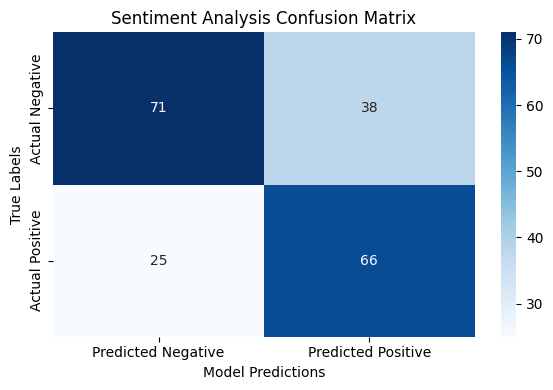

In [ ]:
# Cell 4: Visualising the Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Set up the matplotlib figure
plt.figure(figsize=(6, 4))

# Create a heatmap using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])

# Add labels and title for clarity
plt.title('Sentiment Analysis Confusion Matrix')
plt.xlabel('Model Predictions')
plt.ylabel('True Labels')

# Display the plot
plt.tight_layout()
plt.show()